Assignment 2

Statement of AI: I used AI (Claude) to help me work out how to access the dataset, I also used it to help me debug some code where the error wasn't obvious at first and when I got stuck on a few tasks and couldn't find the answers on gooogle.

Task 0

Part a: my dataset I have chosen is titled 'Wine Rating & Price' and the link to the website is the following https://www.kaggle.com/datasets/budnyak/wine-rating-and-price?select=White.csv

Part b:
The data set has information about a collection of different white wines and has 8 variables: name, country, region, winery, rating, number of ratings, price and year of production.
There are 3764 rows. 
I plan to examine the factors that influence the rating of a wine such as the price and the region. 

In [188]:
#Part c
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_wine = pd.read_csv("C:/Users/maisy/Pythonrepo/White.csv")

#Convert 'Year' Column to float type
df_wine['Year'] = pd.to_numeric(df_wine['Year'], errors='coerce')

# Print Summary Stats
print(df_wine.describe())

            Rating  NumberOfRatings        Price         Year
count  3764.000000      3764.000000  3764.000000  3759.000000
mean      3.817906       187.567216    20.620319  2017.155094
std       0.266827      1071.470441    30.928415     1.842854
min       2.200000        25.000000     3.740000  1993.000000
25%       3.600000        43.000000     9.260000  2016.000000
50%       3.800000        77.000000    13.150000  2018.000000
75%       4.000000       174.250000    20.865000  2018.000000
max       4.900000     62980.000000   681.370000  2020.000000


<Axes: title={'center': 'Relationship between Year and Price'}, xlabel='Year', ylabel='Price'>

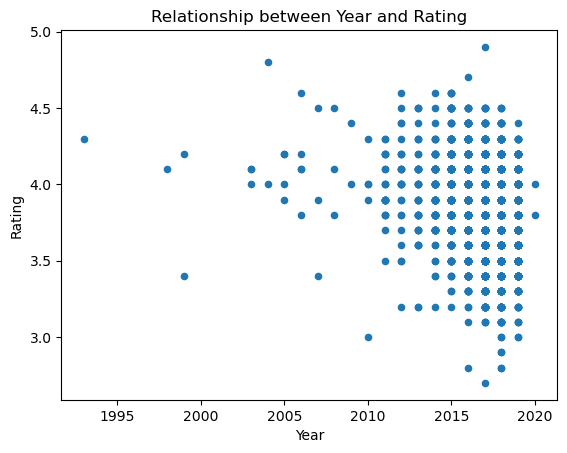

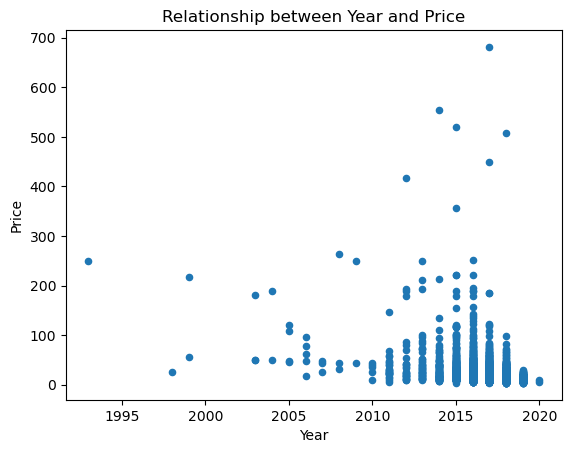

In [189]:
# Visualisations of the data as scatterplot
df_wine.plot(x='Year', y='Rating',  kind='scatter', title='Relationship between Year and Rating')
df_wine.plot(x='Year', y='Price',  kind='scatter', title='Relationship between Year and Price')

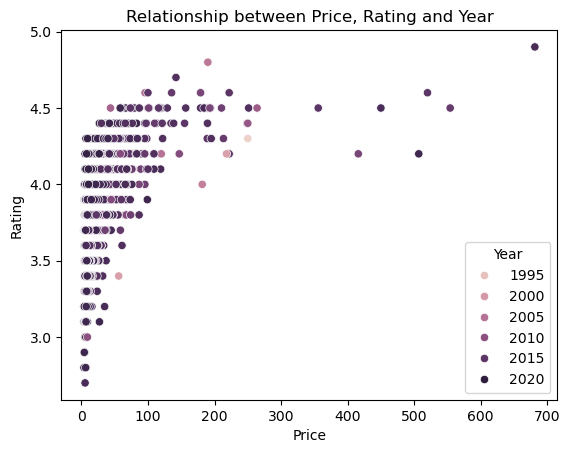

In [190]:
#Visualisation as a sctarrplot
import seaborn as sns
sns.scatterplot(data=df_wine, x="Price", y="Rating", hue="Year")
plt.title("Relationship between Price, Rating and Year")
plt.show()

Task 1

In [191]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("MY_API_KEY")

print(api_key[:5])

483f4


Task 2

In [192]:
# Part a 
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
url="http://api.marketstack.com/v1/eod"

# making the API requests
import requests
all_data = []

for ticker in tickers:#setting the parameters 
        params = {
            "access_key": api_key,
            "symbols": ticker,
            "date_from": "2026-03-01",
            "date_to": "2026-03-31",
            "limit": 1000,
            "sort": "ASC"
        }
#accessing the data using the url and parameters set
        response = requests.get(url, params=params)
        data=response.json()

# putting the data into a dictionary
        for item in data.get("data", []):
            item["ticker"] = ticker
            all_data.append(item)

print("Total records:", len(all_data))

Total records: 110


In [193]:
# Part b 
df_stock=pd.DataFrame(all_data)
display(df_stock.head(5))

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,ticker
0,637.16,659.9400,634.5000,653.56,9801700.0,659.94,634.5000,653.56,637.16,9816125.0,1.0,0.0,META,ARCX,2026-03-02T00:00:00+0000,META
1,648.29,659.0400,638.8400,655.08,12240600.0,659.04,638.8400,655.08,648.29,12263754.0,1.0,0.0,META,ARCX,2026-03-03T00:00:00+0000,META
2,657.96,672.7500,657.6711,667.73,10709535.0,672.77,657.6711,667.73,657.96,10810054.0,1.0,0.0,META,ARCX,2026-03-04T00:00:00+0000,META
3,662.15,670.7000,650.3100,660.57,13249534.0,670.70,650.3100,660.57,661.93,13341367.0,1.0,0.0,META,ARCX,2026-03-05T00:00:00+0000,META
4,647.90,649.4568,636.1800,644.86,13000591.0,649.47,636.1100,644.86,647.90,13159356.0,1.0,0.0,META,ARCX,2026-03-06T00:00:00+0000,META


In [194]:
#Part C
#Creating summary statistics
summary = df_stock.groupby("ticker")["adj_close"].describe()
display(summary)

,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [195]:
# Calculating return percentage
monthly_return = df_stock.groupby("ticker")["adj_close"].agg(
    first_close="first",
    last_close="last"
)

monthly_return["return_percentage"] = (
    (monthly_return["last_close"] - montly_return["first_close"])/montly_return["first_close"] * 100
).round(2)

print("Montly return percentage for each stock:")
display(monthly_return)

Montly return percentage for each stock:


,first_close,last_close,return_percentage
ticker,,,
AAPL,264.72,253.79,-4.13
AMZN,208.39,208.27,-0.06
GOOG,306.36,286.86,-6.37
META,653.56,572.13,-12.46
NFLX,97.09,96.15,-0.97


In [196]:
# Calculating best and worst performer 
best = monthly_return["return_percentage"].idxmax()
worst = monthly_return["return_percentage"].idxmin()

print("Best performer in March is", best)
print("Worst performer in March is", worst)

Best performer in March is AMZN
Worst performer in March is META


Task 3

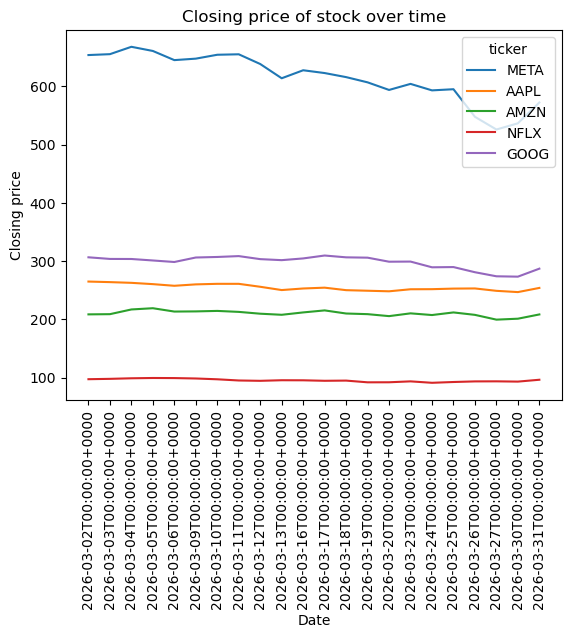

In [197]:
# Part a
sns.lineplot(x="date", y="adj_close", data=df_stock, hue="ticker")
plt.xlabel('Date')
plt.ylabel('Closing price')
plt.title('Closing price of stock over time')
plt.xticks(rotation=90)
plt.show()

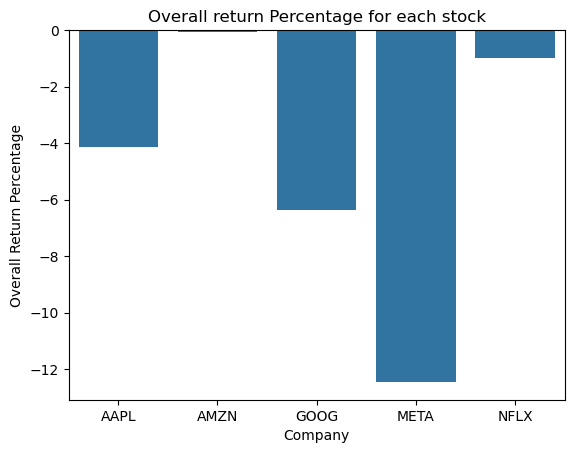

In [198]:
# Part b 
sns.barplot(x="ticker", y="return_percentage", data=monthly_return)
plt.xlabel('Company')
plt.ylabel('Overall Return Percentage')
plt.title('Overall return Percentage for each stock')
plt.show()

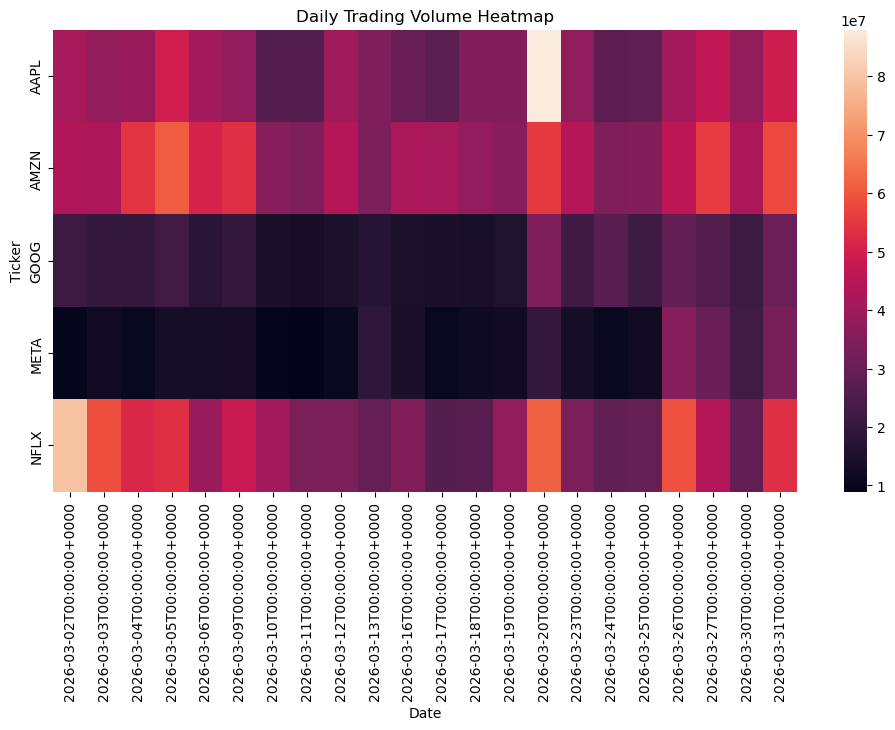

In [199]:
# Part c
volume_pivot = df_stock.pivot_table(index='ticker', columns='date',  values='volume')

plt.figure(figsize=(12,6))
sns.heatmap(volume_pivot)

plt.title('Daily Trading Volume Heatmap')
plt.xlabel('Date')
plt.ylabel('Ticker')
plt.xticks(rotation=90)

plt.show()

Task 4

In [200]:
#Part a
import json 

# creating the folder
directory_name="exports" 
os.makedirs(directory_name, exist_ok=True)

# converting data into JSON string
json_str = json.dumps(all_data, indent=4, default=str)

# write the string into the file
with open("exports/stockdata.json", "w") as f:
    f.write(json_str)

print("Data exported to exports/stockdata.json")

Data exported to exports/stockdata.json


In [201]:
# Part b
df_stock.to_csv("exports/stockdata.csv", index=False)

print("Data exported to exports/stockdata.csv")

Data exported to exports/stockdata.csv


In [202]:
# Part c
# Load back JSON file and print it
with open("exports/stockdata.json",  "r") as f:
    json_str = f.read()
loaded_json = json.loads(json_str)

print("JSON data:")
display(pd.DataFrame(loaded_json).head(5))

# Load back CSV file and print it
loaded_csv = pd.read_csv("exports/stockdata.csv")

print("CSV data:")
display(loaded_csv.head(5))

print("JSON file matches original:", pd.DataFrame(loaded_json).equals(pd.DataFrame(all_data)))
print("CSV file matches original:", pd.DataFrame(loaded_csv).equals(pd.DataFrame(all_data)))

JSON data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,ticker
0,637.16,659.9400,634.5000,653.56,9801700.0,659.94,634.5000,653.56,637.16,9816125.0,1.0,0.0,META,ARCX,2026-03-02T00:00:00+0000,META
1,648.29,659.0400,638.8400,655.08,12240600.0,659.04,638.8400,655.08,648.29,12263754.0,1.0,0.0,META,ARCX,2026-03-03T00:00:00+0000,META
2,657.96,672.7500,657.6711,667.73,10709535.0,672.77,657.6711,667.73,657.96,10810054.0,1.0,0.0,META,ARCX,2026-03-04T00:00:00+0000,META
3,662.15,670.7000,650.3100,660.57,13249534.0,670.70,650.3100,660.57,661.93,13341367.0,1.0,0.0,META,ARCX,2026-03-05T00:00:00+0000,META
4,647.90,649.4568,636.1800,644.86,13000591.0,649.47,636.1100,644.86,647.90,13159356.0,1.0,0.0,META,ARCX,2026-03-06T00:00:00+0000,META


CSV data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,ticker
0,637.16,659.9400,634.5000,653.56,9801700.0,659.94,634.5000,653.56,637.16,9816125.0,1.0,0.0,META,ARCX,2026-03-02T00:00:00+0000,META
1,648.29,659.0400,638.8400,655.08,12240600.0,659.04,638.8400,655.08,648.29,12263754.0,1.0,0.0,META,ARCX,2026-03-03T00:00:00+0000,META
2,657.96,672.7500,657.6711,667.73,10709535.0,672.77,657.6711,667.73,657.96,10810054.0,1.0,0.0,META,ARCX,2026-03-04T00:00:00+0000,META
3,662.15,670.7000,650.3100,660.57,13249534.0,670.70,650.3100,660.57,661.93,13341367.0,1.0,0.0,META,ARCX,2026-03-05T00:00:00+0000,META
4,647.90,649.4568,636.1800,644.86,13000591.0,649.47,636.1100,644.86,647.90,13159356.0,1.0,0.0,META,ARCX,2026-03-06T00:00:00+0000,META


JSON file matches original: True
CSV file matches original: True


Task 5

In [203]:
# Part a
import sqlite3

conn=sqlite3.connect("C:/Users/maisy/northwind.db")

cursor=conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables=cursor.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [204]:
# Part b
product_query = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

df_products = pd.read_sql_query(product_query, conn)

print(df_products)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

In [205]:
#Part c
germany_query="""
SELECT
    Customers.CompanyName,
    Orders.OrderID,
    Orders.OrderDate,
    Orders.ShipCountry,
    ("Order Details".UnitPrice * "Order Details".Quantity) AS LineTotal
FROM Orders
JOIN Customers
    ON Orders.CustomerID = Customers.CustomerID
JOIN "Order Details"
    ON Orders.OrderID = "Order Details".OrderID
WHERE Orders.ShipCountry = 'Germany';
"""

df_germany = pd.read_sql_query(germany_query, conn)
print(df_germany)

              CompanyName  OrderID            OrderDate ShipCountry  LineTotal
0      Toms Spezialitäten    10249           2016-07-05     Germany      167.4
1      Toms Spezialitäten    10249           2016-07-05     Germany     1696.0
2      Ottilies Käseladen    10260           2016-07-19     Germany      123.2
3      Ottilies Käseladen    10260           2016-07-19     Germany      780.0
4      Ottilies Käseladen    10260           2016-07-19     Germany      591.0
...                   ...      ...                  ...         ...        ...
80668    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      864.0
80669    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      735.0
80670    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       75.0
80671    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      500.0
80672    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       77.5

[80673 rows x 5 columns]


Task 6

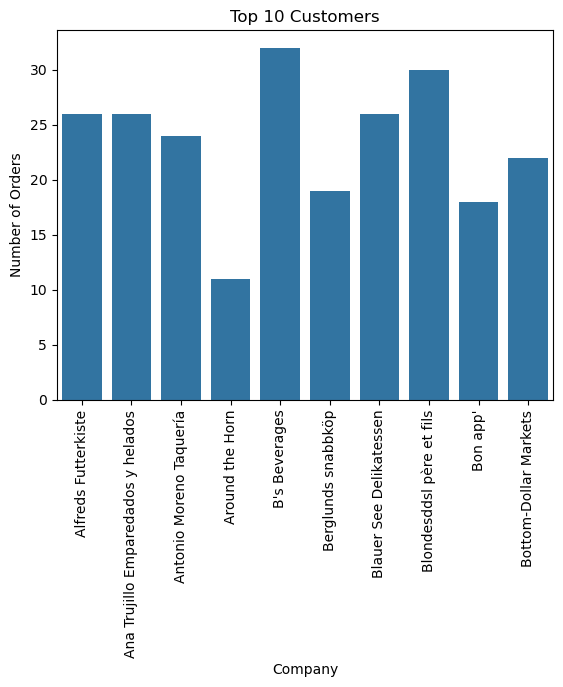

In [206]:
# Part a
# finding top 10 customers
top_customers = df_germany.groupby("CompanyName")["OrderID"].nunique().head(10)

# creating bar plot
sns.barplot(x=top_customers.index, y=top_customers.values)
plt.xlabel('Company')
plt.ylabel('Number of Orders')
plt.title('Top 10 Customers')
plt.xticks(rotation=90)
plt.show()

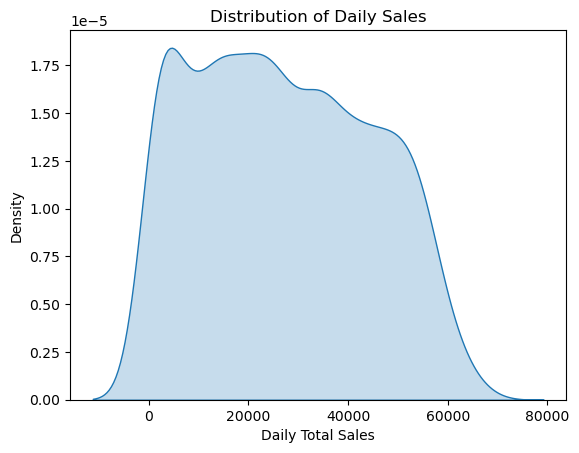

In [207]:
# Part b
# getting data in right place
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum().reset_index()

# making the grapgh
sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)
plt.xlabel('Daily Total Sales')
plt.ylabel('Density')
plt.title('Distribution of Daily Sales')
plt.show()


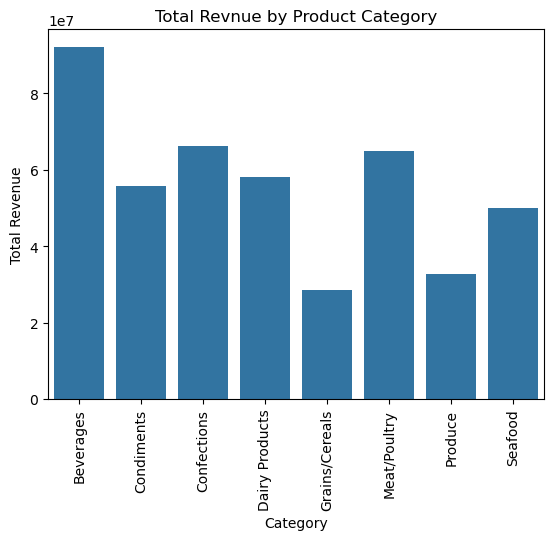

In [208]:
# Part C
#create query
category_query="""
SELECT 
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
INNER JOIN Products
    ON "Order Details".ProductID = Products.ProductID
INNER JOIN Categories
    ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName;
"""

# load into dataframe
df_categories = pd.read_sql_query(category_query, conn)

sns.barplot(data=df_categories, x="CategoryName", y="TotalRevenue")

plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.title('Total Revnue by Product Category')
plt.xticks(rotation=90)
plt.show()

Task 7

In [209]:
# Part a
# Products table
products_query = """
SELECT *
FROM Products;
"""
df_products = pd.read_sql_query(products_query, conn)
print("Products table")
display(df_products.head())

# Categories table
categories_query="""
SELECT *
FROM Categories;
"""
df_categories = pd.read_sql_query(categories_query, conn)
print("Categories table")
display(df_categories.head())

Products table


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [210]:
# Part b
df_joined = pd.merge(df_products, df_categories, on="CategoryID", how="inner")
display(df_joined.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [211]:
# Part c
import time

# SQL approach
start_sql = time.time()

sql_query="""
SELECT 
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
INNER JOIN Products
    ON "Order Details".ProductID = Products.ProductID
INNER JOIN Categories
    ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName;
"""

df_sql = pd.read_sql_query(sql_query, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

# Pandas approach
start_pd = time.time()

df_products = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories = pd.read_sql_query("SELECT * FROM Categories;", conn)
df_orderdetails = pd.read_sql_query("SELECT * FROM 'Order Details';", conn)

df_pd = df_orderdetails.merge(df_products, on="ProductID", how="inner")
df_pd = df_pd.merge(df_categories, on="CategoryID", how="inner")

df_pd["Revenue"] = df_pd["UnitPrice_x"] * df_pd["Quantity"]

df_pd_result=df_pd.groupby("CategoryName")["Revenue"].sum().reset_index()

end_pd= time.time()
pd_time = end_pd - start_pd

print("SQL time was:", sql_time)
print("Pandas time was:", pd_time)

if sql_time < pd_time:
    print("SQL was faster")
else:
    print("Pandas was faster")

SQL time was: 2.316399574279785
Pandas time was: 4.2154154777526855
SQL was faster


Task 8

In [212]:
# adding the data from task
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [213]:
# Part a 
print("Original wide data:")
print(wide_data)

wide_long = pd.melt(wide_data, id_vars=["store"], var_name="quater", value_name="sales")

print("Converted wide to long:")
print(wide_long)

Original wide data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500
Converted wide to long:
       store    quater  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


In [214]:
# Part b
print("Original long data:")
print(long_data)

long_wide = long_data.pivot(index="month", columns="product", values="units_sold").reset_index()

print("Conveted from long to wide:")
print(long_wide)

Original long data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130
Conveted from long to wide:
product month  Laptop  Phone
0         Feb      50    110
1         Jan      45    120
2         Mar      55    130


In [215]:
# Part C
# Restoring long back to wide
wide_restored=wide_long.pivot(index="store", columns="quater", values="sales").reset_index()
wide_restored.columns.name = None

print("restored wide data:")
print(wide_restored)
print("Original wide data:")
print(wide_data)
print("Matches original:", wide_restored.equals(wide_data))

restored wide data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500
Original wide data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500
Matches original: True


In [216]:
# Restoring the wide back to long
long_restored = long_wide.melt(id_vars="month", var_name="product", value_name="units_sold")

print("Restored back to long data:")
print(long_restored)
print("Original long data:")
print(long_data)

#The data between the original and restored is the same, but the order is different meaning it is harder to check the same way as I did above and both would need sorting to use that code.

Restored back to long data:
  month product  units_sold
0   Feb  Laptop          50
1   Jan  Laptop          45
2   Mar  Laptop          55
3   Feb   Phone         110
4   Jan   Phone         120
5   Mar   Phone         130
Original long data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130
